<a href="https://colab.research.google.com/github/uddipta-deka/multiclass-brain-tumor-detection/blob/main/notebooks/1_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [34]:
BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"
DATA_PATH = BASE_PATH + "/dataset"

In [35]:

import os
import random
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd


import cv2
from PIL import Image


import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array



In [36]:
import os
BASE_PATH = "/content/drive/MyDrive/Brain Tumor Classification"
TRAIN_PATH = os.path.join(BASE_PATH, 'dataset', 'Training')
TEST_PATH = os.path.join(BASE_PATH, 'dataset', 'Testing')

if os.path.exists(TRAIN_PATH):
    classes = os.listdir(TRAIN_PATH)


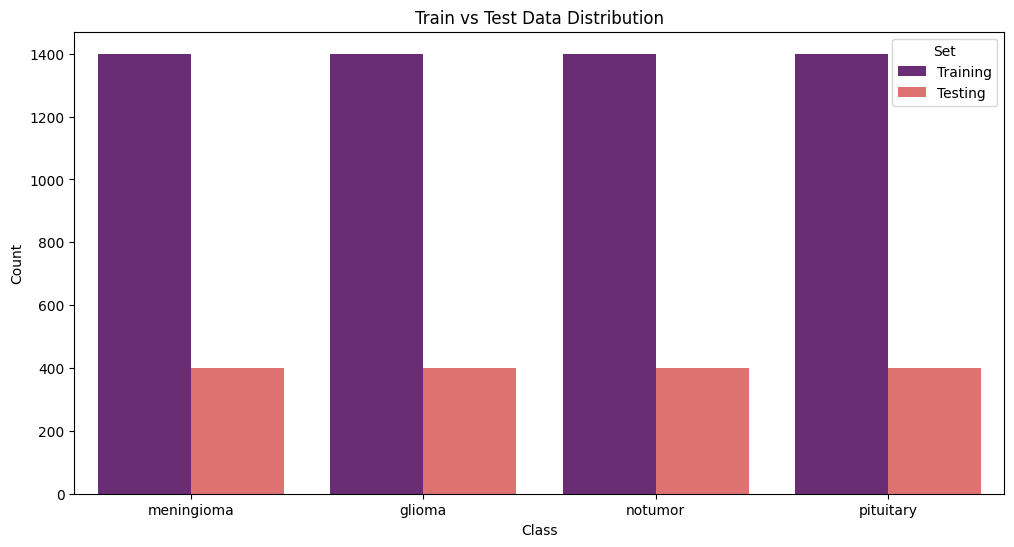

Total Training Images: 5600
Total Testing Images: 1600
Split Ratio: 78% Train / 22% Test


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def count_images(path):
    data = []
    for cls in os.listdir(path):
        if not cls.startswith('.'):
            count = len(os.listdir(os.path.join(path, cls)))
            data.append({'Class': cls, 'Count': count})
    return pd.DataFrame(data)

train_df = count_images(TRAIN_PATH)
train_df['Set'] = 'Training'

test_df = count_images(TEST_PATH)
test_df['Set'] = 'Testing'


full_df = pd.concat([train_df, test_df])

plt.figure(figsize=(12, 6))
sns.barplot(x='Class', y='Count', hue='Set', data=full_df, palette='magma')
plt.title('Train vs Test Data Distribution')
plt.show()


total_train = train_df['Count'].sum()
total_test = test_df['Count'].sum()
print(f"Total Training Images: {total_train}")
print(f"Total Testing Images: {total_test}")
print(f"Split Ratio: {round(total_train/(total_train+total_test)*100)}% Train / {round(total_test/(total_train+total_test)*100)}% Test")

## Dataset Distribution Analysis

- The dataset consists of a total of **7200 MRI images**, divided into training and testing sets.
- The training set contains **5600 images (78%)**, while the testing set contains **1600 images (22%)**.
- This split is appropriate for model training, as a larger portion of data is allocated for learning while maintaining a sufficient test set for evaluation.
- The class distribution across training and testing sets appears to be consistent, ensuring fair performance comparison.

##  Key Insight

- The dataset size is adequate for training deep learning models using transfer learning techniques.
- The chosen split ratio (78:22) supports effective model generalization and reliable evaluation.

In [38]:
train_df.head()


,Class,Count,Set
0,meningioma,1400,Training
1,glioma,1400,Training
2,notumor,1400,Training
3,pituitary,1400,Training


In [39]:
test_df.head()

,Class,Count,Set
0,glioma,400,Testing
1,meningioma,400,Testing
2,notumor,400,Testing
3,pituitary,400,Testing


Sample Images

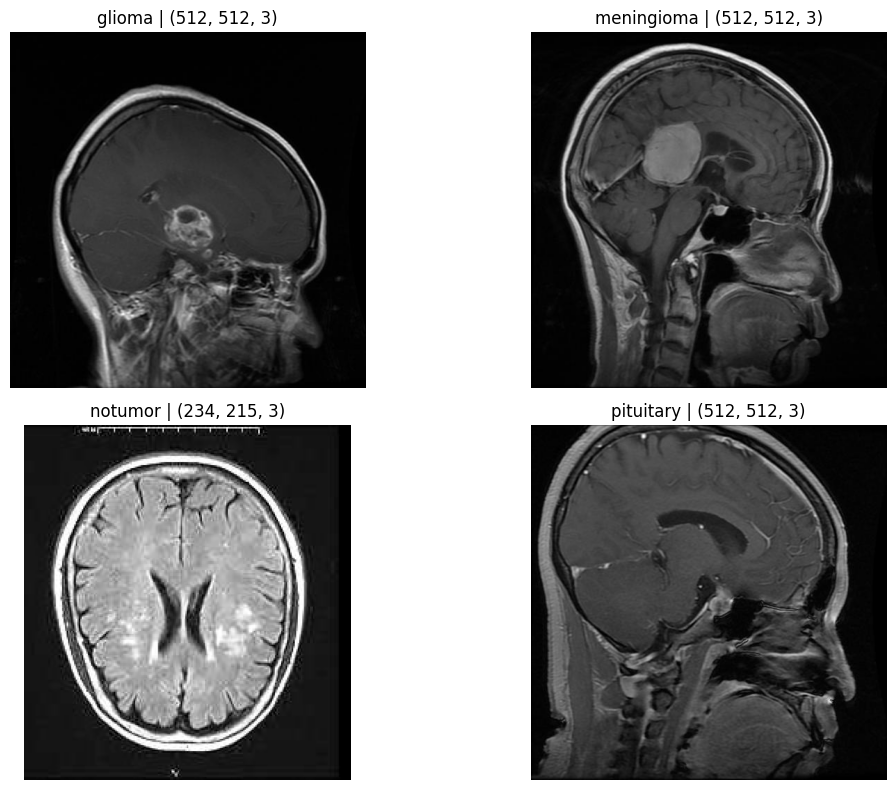

In [41]:
import matplotlib.pyplot as plt
import cv2
import os

def show_samples(path):
    categories = sorted(os.listdir(path))
    categories = [c for c in categories if not c.startswith('.')]

    plt.figure(figsize=(12, 8))

    for i, category in enumerate(categories):
        folder_path = os.path.join(path, category)


        images = [img for img in os.listdir(folder_path) if not img.startswith('.')]

        img_path = os.path.join(folder_path, images[0])

        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 2, i+1)
        plt.imshow(img)
        plt.title(f"{category} | {img.shape}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

show_samples(TRAIN_PATH)

In [43]:
from PIL import Image
import os

sizes = set()

for cls in os.listdir(TRAIN_PATH):
    if cls.startswith('.'): continue

    class_path = os.path.join(TRAIN_PATH, cls)

    for img_name in os.listdir(class_path)[:100]:
        if img_name.startswith('.'): continue

        img_path = os.path.join(class_path, img_name)
        img = Image.open(img_path)
        sizes.add(img.size)

print("Unique image sizes:", sizes)

Unique image sizes: {(200, 210), (630, 630), (507, 605), (350, 350), (420, 280), (233, 210), (491, 624), (206, 244), (409, 442), (275, 301), (400, 442), (800, 693), (339, 340), (442, 454), (550, 664), (236, 236), (232, 217), (1000, 583), (233, 243), (173, 201), (200, 252), (512, 512), (201, 251), (421, 486), (236, 300), (1000, 714), (472, 537), (485, 510), (420, 264), (220, 212), (411, 496), (364, 418), (214, 235), (215, 234), (300, 168), (256, 256), (336, 380), (452, 509), (900, 741), (201, 250), (192, 192), (470, 508), (212, 222), (428, 417), (220, 275), (354, 443), (235, 257), (228, 221), (150, 198), (468, 444), (236, 213), (227, 262), (1149, 1019), (235, 214), (504, 540), (225, 225), (235, 229), (230, 282), (407, 485), (227, 222), (218, 234), (218, 231), (680, 680), (208, 242), (350, 393)}


## Image Resolution Analysis

- The dataset contains images with highly varying resolutions.
- Image dimensions range from small sizes (e.g., 150×198) to large sizes (e.g., 1000×714 and above).
- This variability indicates that the dataset is not standardized in terms of image dimensions.
- Such differences can negatively impact model training, as convolutional neural networks require fixed input sizes.

##  Key Insight

- To ensure consistency and compatibility with pre-trained CNN architectures, all images will be resized to a fixed resolution (e.g., 224×224) during preprocessing.
- Standardizing image size will help improve training stability and model performance.